<img src="images/logo/selene-logo-640.png" style="max-height:75px;" alt="SELENE Logo" />

**Disclaimer:** This Jupyter Notebook contains content generated with the assistance of AI. While every effort has been made to review and validate the outputs, users should independently verify critical information before relying on it. The SELENE notebook repository is constantly evolving. We recommend downloading or pulling the latest version of this notebook from Github.

# Gradient Descent with Momentum

Gradient Descent is the foundational optimization algorithm used to train neural networks. It works by iteratively updating model parameters in the direction of the negative gradient of the loss function, seeking to minimize the error. While effective in many cases, standard Gradient Descent has notable limitations, particularly when the loss landscape is complex. In high-dimensional neural networks, the optimization surface often contains narrow valleys, plateaus, and steep ridges, which can cause vanilla Gradient Descent to oscillate, move slowly, or get stuck in suboptimal regions. These challenges make it difficult to train large neural networks efficiently and effectively.

To overcome these limitations, **Gradient Descent with Momentum** introduces the concept of accumulating velocity from previous updates. The key idea is to "remember" the past gradient directions and use this accumulated information to guide the current update. This has the effect of accelerating convergence in directions with consistent gradients and reducing oscillations in directions with high curvature. Intuitively, momentum methods act like a ball rolling down a hilly landscape: the ball gains speed in flat directions and smooths out the bumps along steep slopes, enabling faster and more stable convergence.

There are several implementations of momentum, each with subtle differences in how they accumulate and apply past gradients. **Polyak momentum**, the classical approach, directly accumulates past updates to form a velocity vector. **Exponentially Weighted Moving Average (EWMA) momentum** smooths the gradient itself using an exponential moving average before applying the update. **Nesterov momentum**, on the other hand, introduces a "look-ahead" step that anticipates the effect of the velocity, often providing faster convergence and better stability in practice. Understanding these different approaches allows practitioners to choose the right method depending on the optimization problem and network architecture.

Learning momentum methods is particularly important for training large neural networks, where standard Gradient Descent alone is often too slow or unstable. Momentum techniques help models navigate complex loss surfaces more efficiently, improving both convergence speed and generalization. In modern deep learning frameworks, these methods form the backbone of many popular optimizers, including SGD with momentum, RMSProp, and Adam. Mastering momentum not only provides practical benefits in training deep models but also deepens one’s understanding of optimization dynamics in high-dimensional parameter spaces.

### Setting up the Notebook

#### Make Required Imports

This notebook requires the import of different Python packages but also additional Python modules that are part of the repository. If a package is missing, use your preferred package manager (e.g., [conda](https://anaconda.org/anaconda/conda) or [pip](https://pypi.org/project/pip/)) to install it. If the code cell below runs with any errors, all required packages and modules have successfully been imported.

In [1]:
import numpy as np

from src.utils.plotting.gd import *

#### Preliminaries

* This notebook assumes a basic understanding of calculus and concepts of derivatives and partial derivatives.
* Although the notebook starts with a brief recap about basic Gradient Descient, being already familiar with this algorithm is recommended.

---

## Quick Recap: Basic Gradient Descent

Gradient Descent is a fundamental optimization technique used to find the minimum of a function when an exact analytical solution is unavailable or impractical to compute. Instead of solving for the minimum directly, Gradient Descent takes an iterative approach: starting from an initial guess, it repeatedly adjusts the parameters in the direction of steepest descent, as indicated by the negative gradient of the function. Intuitively, the gradient tells us how the function changes locally, and by taking small steps downhill, we progressively move closer to a minimum. This makes gradient descent especially powerful for high-dimensional problems where closed-form solutions either do not exist or would be computationally infeasible.

This approach is crucial in the context of neural networks, where the objective function (typically a loss function measuring prediction error) is highly complex and defined over millions (or even billions) of parameters. These loss functions are rarely convex and almost never admit analytical solutions. Gradient descent allows us to efficiently navigate this vast parameter space by leveraging gradients computed via backpropagation. Without such an iterative optimization method, training modern neural networks would simply not be possible. Moreover, gradient descent is flexible and scalable, with many practical variants &mdash; including momentum-based methods, the focus of this notebook &mdash; designed to improve convergence speed and stability.

### Basic Definitions + Algorithm

In most practical optimization settings, including training neural networks, we deal with functions that take many inputs (parameters) but produce a single scalar output. This formulation &mdash; that is, minimizing a multivariate function $ y = f(\mathbf{x}) \in \mathbb{R} $ &mdash; is especially useful because it aligns perfectly with the concept of a loss function. During training, a neural network maps inputs to predictions, which are then compared against targets using a loss function (e.g., Mean Squared Error or Cross-Entropy). Crucially, this loss is a single scalar value that summarizes how well the model is performing across a batch of data. Framing the problem this way allows us to compute partial derivatives of the loss with respect to each parameter, forming the gradient vector that guides optimization.

In the following, therefore, we consider a multivariate function $f$ of the following form:

$$\large
y = f(\mathbf{x}) = f(x_1, x_2, x_3, \dots, x_d)
$$

where $y$ is the scalar output (e.g., the loss when training a neural network), and $d$ (for "dimension") is the number of inputs (parameters). Throughout this notebook we consider a multivariate function as a concrete example as defined below; we limit ourselves to only two inputs here to ease visualization, but all concepts apply to an arbitrary number of inputs.

$$\large
f(x_1, x_2) = 0.1x_1^2 + x_2^2
$$

Just by looking at this function, it is easy to see that this function has its minimum at $x_1 = x_2 = 0$. Of course, we will go through the steps to get there using Gradient Descent. But before that, let's plot the function to see how it looks. For that, we first define a Python method `f()` implementing this function.

In [2]:
def f(x1, x2):
    return 0.1*(x1**2) + (x2**2)

We provide another auxiliary method `plot_multivariate_function()` to plot the function $f(x_1, x_2)$.

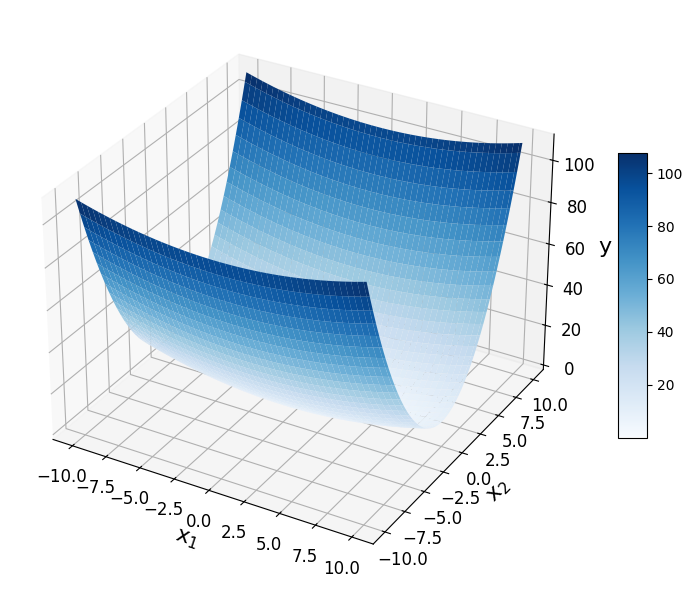

In [3]:
plot_multivariate_function(f)

For the Gradient Descent algorithm, as the name suggests, we also need to be able to compute the gradient for a given set of values for $x_1$ and $x_2$. To this end, we need to compute each **partial derivative** $\large \frac{\partial f}{\partial x_i}$ to measure how $f$ changes when only $x_i$ is varied while all other variables are held fixed. Together, these partial derivatives capture how sensitive the function is to each of its inputs. All partial derivatives can be collected into a single object called the **gradient**:

$$\large
\nabla f = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \dots, \frac{\partial f}{\partial x_n}\right]
$$

For our example function, we therefore need to compute the two partial derivatives $\large \frac{\partial f}{\partial x_1}$ and$\large \frac{\partial f}{\partial x_2}$, which are simply:

$$\large
\frac{\partial f}{dx_1} = 0.2 x_1\ ,\quad \frac{\partial f}{dx_2}= 2 x_2
$$

For a concrete example, let's compute the gradient at position $x_1 = 9$ and $x_2 = -3$. After plugging in both value into the partial derivatives, we get the following gradient vector:

$$\large
\nabla f = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}\right] = \left(1.8, -6\right)
$$

Like function $f$ itself, we can also define the computation of the gradient as a simple Python method `g()` (for "gradient"):

In [4]:
def g(x1, x2):
    return 0.2*x1, 2*x2

The last missing bit for the Gradient Descent algorithm is the **learning rate** commonly denoted using $\eta$. Despite the fancy name, the learning rate is just a scaling factor to scale down the gradient &mdash; in basically all practical cases, the gradient values are too large &mdash; before updating the parameters. By incorporating $\eta$, we get the final update rule for the Gradient Descent algorithm.

$$
\begin{align}
\large \mathbf{x}^{(t+1)}\ &\large = \mathbf{x}^{(t)} - \eta\cdot g\left(\mathbf{x}^{(t)}\right)
\end{align}
$$

We now have everything in place to implement the Gradient Descent algorithm; see the Python method `sgd()` in the code cell below. As input, method `sgd()` receives the following arguments:

* `g`: the method to compute the gradient for a given input $\mathbf{x}$
* `x0`: the initial value of $\mathbf{x}$
* `eta`: the learning rate
* `n_steps`: the number of iterations (i.e., update steps) to be performed

Note that we keep a history of all updates. While this would not be required in practice &mdash; in general, we are only interested in the values for $\mathbf{x}$ after the last update which are hopefully close to the true minimum &mdash; we can use the history of updates for visualizing the results.

In [5]:
def sgd(g, x0, eta, n_steps):
    # Initialize history of x values
    x, xs = x0, [x0]
    # Run basic Gradient Descent for n_steps iterations
    for _ in range(n_steps):
        # Compute the gradient for current x values using derivative
        gradient = np.asarray(g(*x))
        # Update x values based on gradient and learning rate
        x = x - eta*gradient
        # Add updated x values to history
        xs.append(x)
    # Return history of x values as a NumPy array
    return np.asarray(xs)

To show the usage of method `sgd()`, we first need to define an initial value for `x0`. To be in line with the example above, let's pick position $x_1 = 9$ and $x_2 = -3$ as the starting point; in fact, we will be using the same function $f$ and the same starting point for all subsequent examples. The code cell below defines the `x0` as a NumPy array.

In [6]:
x0 = np.asarray([9, -3])

We can now perform Gradient Descent by executing method `sgd()`. By default, we set the learning `eta` to $0.1$ and the number of iterations `n_steps` to `100`. However, you are welcome and encouraged to vary both parameters, particularly the learning rate, to see how these changes will affect the result. That being said, the default parameters are meaningful enough to illustrate the limitations of basic Gradient Descent and motivate the advantages of momentum-based extensions to the algorithm.

In [7]:
eta, n_steps = 0.1, 100

xs_sgd = sgd(g, x0, eta, n_steps)

Right now, with `xs_sgd`, we only have the history of all parameter updates. To see the actual behavior of the Gradient Descent implementation, we provide the auxiliary method `plot_gradient_descent_2d()` to visualize the update steps in a plot. Apart from the update history `xs_sgd`, this method also receives `f` to visualize the 2d function as contour plot, and `eta` for setting the title of the plot. Just run the code cell below to generate the animated plot (note that this might take a few seconds).

In [8]:
plot_gradient_descent_2d(f, xs_sgd, eta=eta, title=f"Gradient Descent (η = {eta})")

As the animation shows, Gradient Descent systematically updates the parameters (here: $\mathbf{x}$) to get close and close to the minimum. However, the animation also shows some potential issues. For one the trajectory does seem to take a "detour" instead of following a more direct path. Also notice how the updates seem to slow down when getting closer and closer to the minimum &mdash; and, in fact, not reaching it using the default parameters of `eta=0.1` and `n_steps=100`. Thus, in the next section, we need to look a bit more closely at the different limitations and challenges when using the basic Gradient Descent algorithm.

### Limitations & Challenges

Overall, the basic Gradient Descent algorithm is sound in that it provides a well-defined and systematic way to find the minimum of a function using an iterative optimization approach &mdash; due to the lack of an analytical solution. But even when only considering our previous example, which arguably represents a very simple function, there are some limitations and challenges when it comes to using the algorithm in real-world situations such as training neural network; these particularly include:

#### Slow Convergence in Flat Regions (Plateaus)

To better understand this issue, let's have another look at our example function $f$ &mdash; you can also see the shape of $f$ in the contour plot, but it is arguably a bit more obvious in the 3d plot; still check out both for comparison.

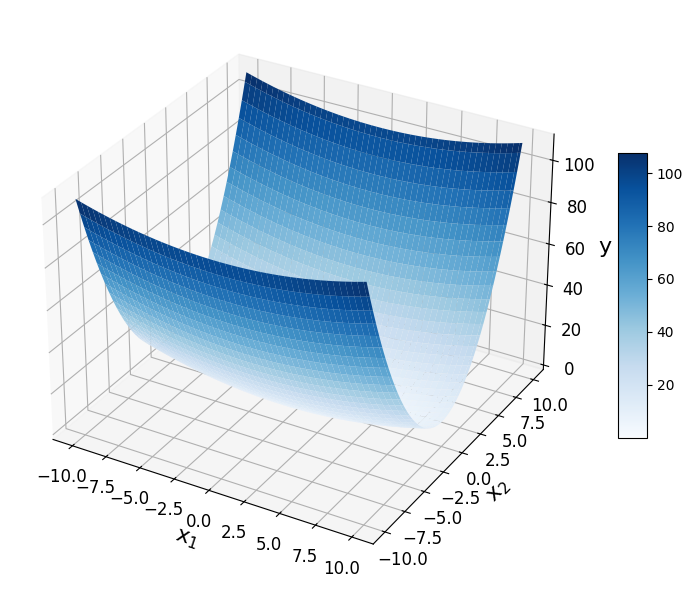

In [9]:
plot_multivariate_function(f)

Although we know, that there is only a single minimum at $x_1=x_2=0$, the function is also what is called **elongated** or **ill-conditioned**. This means that its curvature differs significantly across directions in the parameter space. Geometrically, this often appears as a long, narrow valley: the function changes very steeply along one direction but only slowly along another. As a result, the gradient tends to point steeply toward the sides of the valley rather than directly toward the minimum, which makes optimization more difficult. Such behavior commonly arises when input features are on very different scales; recall that our function is $f(x_1, x_2) = 0.1x_1^2 + x_2^2$.

A main problem with long and narrow valleys is that these regions are typically quite flat. This, in turn, means that the gradients in those regions become very small, and so do therefore the parameter updates &mdash; particularly after scaling down the gradient even further using the learning rate. This is the reason why the progress seems to slow down for example function when viewing the animation. Have another look at the animated plot above, and appreciate how the progress of the update line starts rather fast but quickly gets slower and slower once the updates reach the value.

#### Oscillations in High-Curvature Regions

The seemingly obvious way to address a slow convergence would be to increase the learning rate. However, keep in mind that ill-conditioned functions still change steeply with respect to some dimensions due to features being on (very) different scales. Thus, increasing the learning rate may yield an inefficient and unstable convergence. Instead of moving smoothly toward the minimum, the algorithm tends to **zig-zag** across the narrow valley, making slow progress along the shallow direction while overshooting in the steep direction.

We can show this behavior using our example function but using a large learning rate such as $0.8$ (the default value in the code cell below).

In [10]:
eta, n_steps = 0.8, 100

xs_sgd = sgd(g, x0, eta, n_steps)

plot_gradient_descent_2d(f, xs_sgd, eta=eta, title=f"Gradient Descent (η = {eta})")

On the one hand, increasing the learning rate speeds up the convergence, and in this case we essentially reach the minimum after 100 epochs. However, this zig-zag behavior only looks "harmless" here because our function is very simple: the function is very smooth and has only a single global minimum. In practice, loss functions typically exhibit much more complex shapes and zig-zag trends are more likely to negatively affect the convergence and results. This often forces the use of very small learning rates to maintain stability, which further slows convergence; see above.

#### Vulnerability to Local Minima and Saddle Points

While our example function is arguably ill-conditioned, it is still a rather simple function that is very smooth and features only a single global minimum. In the context of neural networks, however, the loss function we aim to minimize is often highly complex due to the combination of multiple layers, non-linear activation functions, and interactions between a large number of parameters. Unlike simple convex functions, the loss surface of a neural network is rarely smooth or bowl-shaped. Instead, it can contain many **"bumps"** (i.e., abrupt changes in gradient) as well as **multiple local minima** and **saddle points**, where the gradient is zero (or near-zero) but the point is neither a minimum nor a maximum. This complexity is a natural consequence of modeling high-dimensional, non-linear relationships between inputs and outputs, especially when training on large, real-world datasets.

For basic Gradient Descent, such intricate loss landscapes pose significant challenges. The algorithm updates parameters solely based on the **local gradient**, without any awareness of the broader shape of the surface. This means that if the optimization path encounters a local minimum or gets too close to a saddle point, gradient descent may **stall or converge prematurely**, failing to find a better solution. Similarly, if the surface contains sharp bumps, the gradient can fluctuate dramatically, leading to **unstable updates** that overshoot the minimum or oscillate around it. These effects slow down convergence and make it harder to achieve optimal performance.

Summing up, want we want are optimization methods that are able to push through saddle points or jump/ignore small bumps (incl. local minima) &mdash; in short, better handle ill-condition loss surfaces (or ill-conditioned functions, in general). This is where momentum-based methods come into play.

---

## Momentum Methods

The core intuition behind momentum-based methods is that parameter updates should not depend solely on the *current* gradient &mdash; as in basic Gradient Descent &mdash; but should also incorporate information from **past gradients**. Instead of treating each step independently, momentum methods build up a kind of "velocity" vector that accumulates direction over time. This makes optimization behave less like a cautious walker and more like a rolling ball that gathers speed in consistent directions. This "rolling ball" behavior has several advantages

* **Speed up convergence:** In regions where gradients consistently point in the same direction (e.g., along a shallow slope), basic Gradient Descent takes many small, repetitive steps. Momentum, however, reinforces these consistent gradients, increasing the step size along that direction. As a result, it can move much faster across flat or gently sloped regions of the loss surface.

* **Reduce oscillations:** Basic Gradient Descent tends to zigzag across such valleys because the gradient direction changes sharply between steps. Momentum dampens these oscillations by averaging gradients over time, smoothing out abrupt directional changes. This leads to more stable and directed progress toward a minimum.

* **More robust to "bumpy" or noisy loss surfaces**. Real-world loss functions, especially in deep learning, often contain many irregularities, such as small local minima or saddle points. By accumulating past gradients, momentum effectively "filters out" high-frequency noise and prevents the optimizer from getting stuck or slowed down by minor fluctuations. In this sense, it acts like a low-pass filter, allowing the optimization process to focus on the broader trend of the loss surface rather than getting distracted by every (minor) bump.

The idea of momentum &mdash; that is, incorporating past gradients into the parameter update &mdash; is a general and powerful concept that underlies many modern optimization algorithms such as Adam. In this notebook, however, we focus on basic momentum-based methods to build intuition step by step. In particular, we will explore 
* Polyak Momentum,
* Exponentially Weighted Average Momentum (EWAM), and
* Nesterov Momentum.
  
These methods illustrate how the simple idea of combining past and present gradients leads to more efficient and stable optimization, and they form the conceptual foundation for more advanced optimizers used in modern deep learning. So let's dive in!

### Standard Momentum (Polyak Momentum)

**Polyak Momentum** (also called *classical momentum*) is one of the earliest and simplest extensions of Gradient Descent, introduced by Boris Polyak in 1964. Its key motivation comes from the observation that basic Gradient Descent can be slow and unstable, especially on loss surfaces that are elongated, noisy, or "bumpy". Polyak Momentum addresses this by introducing a *velocity term* $\mathbf{v}^{(t)}$ that accumulates past gradients up to iteration $t$, allowing the optimization process to build up speed in directions that consistently reduce the loss, while dampening oscillations in directions that frequently change.

Formally, instead of updating parameters directly using the current gradient, Polyak Momentum maintains a running update vector $\mathbf{v}^{(t)}$ (velocity) defined as

$$
\begin{align}
\large \mathbf{v}^{(t+1)}\ &\large = \beta\mathbf{v}^{(t)} + \eta\cdot g\left(\mathbf{x}^{(t)}\right)\\[0.5em]
\large \mathbf{x}^{(t+1)}\ &\large = \mathbf{x}^{(t)} - \mathbf{v}^{(t+1)}
\end{align}
$$

Here, $\beta \in [0,1]$ controls how much past gradients influence the current update. Intuitively, this creates a smoothing effect: the optimizer follows an averaged direction over time rather than reacting to every fluctuation in the gradient. As a result, Polyak Momentum can converge faster, exhibit less zig-zagging in narrow valleys, and be more robust to irregular loss landscapes compared to basic Gradient Descent.

Like before for the basic Gradient Descent algorithm, we can implement the Polyak Momentum method as Python method; see the code cell below which directly extends the `sgd()` method by incorporating the running update vector into the update step in each iteration.

In [11]:
def sgd_polyak(g, x, beta, eta, n_steps):
    # Initialize history of x values
    xs = [x]
    v = np.zeros_like(x)
    # Run basic Gradient Descent for n_steps iterations
    for _ in range(n_steps):
        # Compute the gradient for current x values using derivative
        gradient = np.asarray(g(*x))
        # Update the velocity vector v
        v = beta*v + eta*gradient
        # Update x values based on gradient and learning rate
        x = x - v
        # Add updated x values to history
        xs.append(x)
    # Return history of x values as a NumPy array
    return np.asarray(xs)

The hyperparameter $\beta$ (`beta`) &mdash; also sometimes called the momentum coefficient &mdash; controls how much of the past velocity is carried over to the current update. Its value is typically chosen in the range **0.5 to 0.99**, depending on the problem and the desired behavior. Here are some common ranges for $\beta$ and how the choice its value will generally affect the optimization:

* **Small $\beta$ (e.g., 0.5–0.7):** Here, less weight is given to past gradients, and updates are closer to standard Gradient Descent. This generally means that oscillations in narrow valleys are reduced only slightly, and that convergence speed improves moderately in directions with consistent gradients.

* **Medium $\beta$ (e.g., 0.8–0.9):** Past gradients start to have more influence, creating a stronger "velocity" effect. Parameter updates become  smoother, oscillations across steep directions are more dampened, and progress along shallow directions becomes faster. This is a commonly used range in practice.

* **High $\beta$ (e.g., 0.95–0.99):** The influence of past gradients is not very string, and updates behave like a rolling ball that builds up significant momentum. It can accelerate convergence along long and consistent slopes, but it may overshoot minima if the learning rate is too high, or react slowly to sudden changes in gradient direction.

To see the effects of the different parameters &mdash; not only of $\beta$ but also of the learning rate $\eta$ and the number of iterations &mdash; we can use the method `sgd_polyak()` to find the minimum for our example function. We use the same start parameter `x0` to allow for a direct comparison with `sgd()`, i.e., basic Gradient Descent. In the code cell below, by default, we use the same values for learning rate and number iterations as before, and set $\beta = 0.9$ (a common choice).

In [12]:
beta, eta, n_steps = 0.9, 0.1, 100

xs_polyak = sgd_polyak(g, x0, beta, eta, n_steps)

We can now use the auxiliary method `plot_gradient_descent_2d()` again to visualize the update history.

In [13]:
plot_gradient_descent_2d(f, xs_polyak, eta=eta, title=f"Polyak Momentum (η = {eta})")

Using the default values, we can see how the velocity vector builds up at the beginning since the gradients are quite large in that region. Because of this momentum it takes a few iterations to correct itself to adjust to the loss surface. When the optimization landscape changes direction rapidly (e.g., sharp turns in a valley), the accumulated momentum can keep pushing the optimizer in the old, wrong direction, making it slow to react to the new direction. Of course, we can compensate for that by reducing the momentum coefficient $\beta$ and/or the learning rate $\eta$ &mdash; for example, try $\beta=0.6$ and see how it affects the results. The main advantage, however, is that the momentum avoids the slowdown of the updates in the "flat region" near the minimum.

### Exponentially Weighted Moving Average (EWMA) Momentum

**Exponentially Weighted Moving Average (EWMA) momentum** is a refinement of basic momentum methods such as Polyak Momentum that explicitly frames the momentum term as an exponentially weighted moving average of past gradients. The motivation comes from the observation that simply accumulating past gradients can introduce bias, especially early in training, because the optimizer has "seen" only a few gradients. By weighting past gradients exponentially &mdash; remember that $\beta$ is less than $1$ &mdash; EWMA momentum gives more importance to recent gradients while still incorporating the history, allowing the optimizer to respond quickly to changing directions without losing the benefits of accumulated momentum.

Formally, EWMA momentum defines the velocity (momentum) as:

$$
\begin{align}
\large \mathbf{v}^{(t+1)}\ &\large = \beta\mathbf{v}^{(t)} + (1-\beta)g\left(\mathbf{x}^{(t)}\right)\\[0.5em]
\large \mathbf{x}^{(t+1)}\ &\large = \mathbf{x}^{(t)} - \eta\cdot \mathbf{v}^{(t+1)}
\end{align}
$$

The key difference from classical Polyak momentum is the exponential weighting factor $(1-\beta)$, which prevents the velocity from growing too large and allows for bias correction during early iterations. Intuitively, EWMA momentum provides a smoothed gradient direction that balances the current gradient with past trends, leading to faster, more stable convergence and reducing sensitivity to noisy or highly irregular loss surfaces.

Let's implement EWMA momentum and compare it to basic Gradient Descent and Polyak Momentum; see the method `sgd_ewma()` in the code cell below.

In [14]:
def sgd_ewma(g, x, beta, eta, n_steps):
    # Initialize history of x values
    xs = [x]
    v = np.zeros_like(x)
    # Run basic Gradient Descent for n_steps iterations
    for t in range(n_steps):
        # Compute the gradient for current x values using derivative
        gradient = np.asarray(g(*x))
        # Update the velocity vector v
        v = beta*v + (1-beta)*gradient
        # Update x values based on gradient and learning rate
        x = x - eta*v
        # Add updated x values to history
        xs.append(x)
    # Return history of x values as a NumPy array
    return np.asarray(xs)

For a direct comparison, we test the implementation using the same example function and the same values for all hyperparameters (i.e., momentum coefficient $\beta$, learning rate $\eta$, and the number of iterations), as well as the same starting point `x0`. Just run the code cell below to perform EWMA momentum and get the complete update history.

In [15]:
beta, eta, n_steps = 0.9, 0.1, 100

xs_ewma = sgd_ewma(g, x0, beta, eta, n_steps)

Now we can again visualize the update history using an animated plot.

In [16]:
plot_gradient_descent_2d(f, xs_ewma, eta=eta, title=f"EWMA Momentum (η = {eta})")

As the plot shows, the use of EWMA momentum momentum typically leads to **smoother and more stable updates** compared to classic Polyak Momentum. By weighting recent gradients more heavily, EWMA momentum ensures that parameter updates follow the true underlying trend of the loss surface rather than being overly influenced by old gradients or noisy fluctuations. This results in faster convergence along consistent directions and less zig-zagging in narrow or steep valleys, making the optimization process more efficient and reliable. Overall, EWMA momentum provides a balance between responsiveness to new gradient information and stability from accumulated momentum, which makes it particularly effective on bumpy or irregular loss surfaces.

To better see the exponential weights &mdash; which are arguably not that obvious from the recursive definition of the velocity vector &mdash; we can expand the full formula for various $\mathbf{v}^{(t)}$ by plugging in the expressions for $\mathbf{v}^{(t-1)}$ starting from $\mathbf{v}^{(0)} = \mathbf{0}$. This gives us the following sequence of equations &mdash; note that we write $g^{(t)}$ as a shorthand for $g\left(\mathbf{x}^{(t)} \right)$ to simplify the expressions:

$$
\begin{align}
\large \mathbf{v}^{(1)}\ &\large = (1-\beta)g^{(0)}\\[0.5em]
\large \mathbf{v}^{(2)}\ &\large = \beta\mathbf{v}^{(1)} + (1-\beta)g^{(2)} = (1-\beta)\left(\beta g^{(1)} + g^{(2)} \right)\\[0.5em]
\large \mathbf{v}^{(3)}\ &\large = \beta\mathbf{v}^{(2)} + (1-\beta)g^{(3)} = (1-\beta)\left(\beta^2 g^{(1)} + \beta g^{(2)} + g^{(3)} \right) \\[0.5em]
\large \mathbf{v}^{(4)}\ &\large = \beta\mathbf{v}^{(3)} + (1-\beta)g^{(4)} = (1-\beta)\left(\beta^3 g^{(1)} + \beta^2 g^{(2)} + \beta g^{(3)} + g^{(4)} \right) \\[0.5em]
\large \mathbf{v}^{(5)}\ &\large = ...
\end{align}
$$

Seeing the overall trend, we can generalize the formula for $\mathbf{v}^{(t)}$ to get:

$$
\begin{align}
\large \mathbf{v}^{(t+1)}\ &\large = (1-\beta)\sum_{i=1}^{t}\beta^{i}g^{(t-i)}
\end{align}
$$

Here, we can clearly see how the weights $\beta^{i}$ exponentially scale down the past gradient depending on their "age".

An additional consideration when using EWMA momentum is that the averaging process is typically initialized at $\mathbf{v}^{(0)} = \mathbf{0}$, meaning that in the early iterations the accumulated value is biased toward zero rather than reflecting the true scale of the gradients. As a result, the momentum estimate is systematically underestimated at the start of training, especially when $\beta$ is close to $1$ (which makes the averaging window effectively long). To address this issue, a **bias correction term** is commonly introduced. To derive this term, let's assume for intuition that the gradients $g^{(i)}$ are roughly stationary, i.e., $\mathbb{E}\left(g^{(i)}\right) = \mu$. With this, we can rewrite the previous formula as follows:

$$
\begin{align}
\large \mathbf{v}^{(t+1)}\ &\large = (1-\beta)\sum_{i=1}^{t}\beta^{i}g^{(t-i)}\\[0.5em]
&\large = (1-\beta)\sum_{i=1}^{t}\beta^{i}\mu\\[0.5em]
&\large = \mu(1-\beta)\sum_{i=1}^{t}\beta^{i}\\[0.5em]
\end{align}
$$

Recognizing that the sum is a finite geometric series with a standard closed-form formula, we get:

$$
\begin{align}
\large \mathbf{v}^{(t+1)}\ &\large = \mu(1-\beta)\sum_{i=1}^{t}\beta^{i}\\[0.5em]
&\large = \mu(1-\beta)\frac{1-\beta^{t+1}}{1-\beta}\\[0.5em]
&\large = \mu(1-\beta^{t+1})\\[0.5em]
\end{align}
$$

Since $\beta < 1$, we underestimate the gradient: instead of estimating $\mu$, the EWMA momentum estimate is scaled down by a factor $(1 - \beta^t)$, which is especially small for early $t$. To remove this bias, we simply divide by the following factor, i.e., the bias correction term:

$$\large
\mathbf{\hat{v}}^{(t+1)} = \frac{\mathbf{v}^{(t+1)}}{1 - \beta^{t+1}}
$$

This correction step effectively compensates for the missing contribution from earlier (nonexistent) gradients. It ensures that the EWMA momentum estimate is unbiased, particularly during the initial steps, leading to more accurate and stable parameter updates early in training. Last modification is then simply to use this correction for the update step:

$$
\begin{align}
\large \mathbf{x}^{(t+1)}\ &\large = \mathbf{x}^{(t)} - \eta\cdot \mathbf{\hat{v}}^{(t+1)}
\end{align}
$$

We can now implement the method `sgd_ewma_corrected()` that improves on the initial EWMA momentum implementation to include the bias correction.

In [17]:
def sgd_ewma_corrected(g, x, beta, eta, n_steps):
    # Initialize history of x values
    xs = [x]
    v = np.zeros_like(x)
    # Run basic Gradient Descent for n_steps iterations
    for t in range(n_steps):
        # Compute the gradient for current x values using derivative
        gradient = np.asarray(g(*x))
        # Update the velocity vector v
        v = beta*v + (1-beta)*gradient
        # Bias correction
        v_corrected = v / (1 - beta**(t+1))
        # Update x values based on gradient and learning rate
        x = x - eta*v_corrected
        # Add updated x values to history
        xs.append(x)
    # Return history of x values as a NumPy array
    return np.asarray(xs)

Of course, we can use this implementation to find the minimum for our running example, using the same default value for the hyperparameters to compare it with all previous implementations (incl. EWMA momentum without bias correction). Just run the code cell below to compute the update history.

In [18]:
beta, eta, n_steps = 0.9, 0.1, 100

xs_ewma_corrected = sgd_ewma_corrected(g, x0, beta, eta, n_steps)

And again, let's visualize the update history by creating an animated plot using the auxiliary method `plot_gradient_descent_2d()`.

In [19]:
plot_gradient_descent_2d(f, xs_ewma_corrected, eta=eta, title=f"EWMA Momentum Corrected (η = {eta})")

Just by eye-balling the plots for EWMA momentum with and without bias correction, you probably will not be able to see any obvious differences &mdash; but you would see differences when inspecting the raw values in both update histories. For simple and smooth functions, like our example function, the gradients tend to change slowly and remain relatively consistent across iterations. This means the true average gradient is fairly stable, so even if EWMA momentum underestimates its magnitude slightly in the early steps (due to the bias), the direction of the update is still largely correct. As a result, the optimization trajectory is not significantly affected. Additionally, the bias term $(1 - \beta^t)$ approaches 1 very quickly as $t$ increases, especially after just a few iterations. For smooth problems that do not require many delicate early updates, this short-lived bias has little practical impact, so the benefit of explicit bias correction is often negligible.

### Nesterov Momentum

In methods like Polyak momentum and EWMA momentum, the gradient is evaluated at the current parameters, and then a velocity term accumulates past gradients to smooth and accelerate updates. However, this can lead to overshooting or oscillations, especially in regions where the loss surface curves sharply, because the method does not account for where the momentum is about to take the parameters next.

The main motivation behind **Nesterov Momentum** is to make momentum-based updates more "anticipatory" rather than purely reactive. It improves this by computing the gradient not at the current position, but at a lookahead position, i.e., the point where the parameters would be after applying the current momentum step. This allows the optimizer to “see ahead" and adjust its update before fully committing, leading to more accurate and stable steps. Intuitively, it acts like a correction mechanism on top of momentum, reducing overshooting and improving convergence behavior, particularly in curved or rapidly changing regions of the loss surface.

Mathematically, Nestorov Momentum is defined as follows:

$$
\begin{align}
\large \mathbf{v}^{(t+1)}\ &\large = \beta\mathbf{v}^{(t)} + \eta\cdot g\left(\mathbf{x}^{(t+1)} - \beta\mathbf{v}^{(t)}\right)\\[0.5em]
\large \mathbf{x}^{(t+1)}\ &\large = \mathbf{x}^{(t)} - \mathbf{v}^{(t+1)}
\end{align}
$$

Compared to standard Polyak Momentum, the main difference is in the term $g\left(\mathbf{x}^{(t+1)} - \beta\mathbf{v}^{(t)}\right)$, where the gradient is not computed with respect to the current parameter values $\mathbf{x}^{(t+1)}$ but for the values we would have if we would perform the update with the current velocity vector $\mathbf{v}^{(t)}$ (and the momentum coefficient $\beta$). In terms of the implementation, this represents only a minor change to the `sgd_polyak()` method, giving us the `sgd_nesterov()` method as shown in the code cell below.

In [20]:
def sgd_nesterov(g, x, beta, eta, n_steps):
    # Initialize history of x values
    xs = [x]
    v = np.zeros_like(x)
    # Run basic Gradient Descent for n_steps iterations
    for _ in range(n_steps):
        # Compute the gradient for current x values using derivative
        gradient = np.asarray(g(*x + beta*v))
        # Update the velocity vector v
        v = beta*v - eta*gradient
        # Update x values based on gradient and learning rate
        x = x + v
        # Add updated x values to history
        xs.append(x)
    # Return history of x values as a NumPy array
    return np.asarray(xs)

Let's use this method to find the minimum of our example function $f$ by computing all updates...

In [21]:
beta, eta, n_steps = 0.9, 0.1, 100

xs_nesterov = sgd_nesterov(g, x0, beta, eta, n_steps)

...and plot the update history using our auxiliary method `plot_gradient_descent_2d()`.

In [22]:
plot_gradient_descent_2d(f, xs_nesterov, eta=eta, title=f"Nesterov Momentum (η = {eta})")

Compared to Polyak Momentum and EWMA momentum, Nesterov Momentum updates are typically more cautious and better directed &mdash; as we can also see when comparing the plots for the different methods &mdash; even though they still benefit from acceleration. With Polyak/EWAM, the momentum term can build up and push the parameters strongly in one direction, sometimes leading to overshooting or oscillations, especially in regions where the loss surface curves or changes quickly. The updates are somewhat "blind", since the gradient is evaluated only at the current position, not accounting for where momentum is about to take the parameters.

In contrast, Nesterov Momentum evaluates the gradient at a lookahead position, which acts like an early correction. As a result, updates tend to slow down before overshooting, adjust direction sooner, and follow the curvature of the loss surface more closely. In practice, this often leads to smoother, more stable convergence and can reduce oscillations, particularly in narrow valleys or ill-conditioned problems.

---

## Discussion

### Theoretical Foundations

The idea behind momentum-based methods is quite intuitive: instead of relying only on the current gradient, they incorporate information from past gradients to guide the update. At the same time, these methods are not just heuristic tricks; they are grounded in solid theoretical foundations. Connections exist to areas such as accelerated optimization methods, dynamical systems, and even physical analogies like motion with friction. These perspectives help explain why momentum can improve convergence rates and stability under certain conditions. However, fully understanding these theoretical results typically requires more advanced mathematical tools and goes beyond an introductory treatment.

For most practical purposes, it is not necessary to dive into these deeper theories to benefit from momentum-based methods. It is often sufficient to understand the core intuition (i.e., accumulating past gradient information) and to observe how this changes the behavior of parameter updates compared to basic Gradient Descent. This intuition already provides a strong foundation for applying and tuning these methods effectively in real-world machine learning tasks.

### Training Neural Networks

In this notebook, we have introduced momentum-based optimization methods in the context of general multivariate functions, where the goal is to minimize a function $f(\mathbf{x})$ with respect to a parameter vector $\theta$. In this setting, momentum helps accelerate convergence by accumulating information from past gradients, leading to smoother and often faster updates compared to basic Gradient Descent. These ideas were presented in a general mathematical form, independent of any specific application.

Importantly, all of these concepts translate directly to training neural networks. In that context, we typically denote the parameter vector as $\mathbf{w}$ to refer to all weights and biases of the network. The loss function $\mathcal{L}(\mathbf{y}; \mathbf{X}, \mathbf{w})$ measures how well the network performs on a given task with respect to the training data (feature vectors $\mathbf{X}$ and target labels $\mathbf{}$), as well as the current values for $\mathbf{w}$. All gradients $\large \frac{\partial \mathcal{L}}{\partial \mathbb{w}}$ are computed via backpropagation. Momentum-based methods, such as Polyak Momentum, EWMA momentum, or Nesterov Momentum, can then be applied without modification to update these parameters.

This means that the same intuition carries over: instead of updating weights and biases based only on the current gradient, we incorporate information from previous updates to guide learning more effectively. As a result, training can become more stable, less sensitive to noise, and often faster, especially in deep networks with complex loss surfaces.

### Beyond Basic Momentum Methods

In modern deep learning practice, classical momentum-based methods such as Polyak Momentum, EWAM-style momentum, and Nesterov Momentum are less frequently used as standalone optimizers. They have largely been superseded by more advanced optimization algorithms like **Adam** and its variants, which combine momentum ideas with adaptive learning rates and additional normalization mechanisms. These modern optimizers tend to be more robust across a wide range of architectures and hyperparameter settings, which makes them the default choice in many practical applications.

However, it is important to recognize that most of these modern optimizers are still fundamentally built on the same core idea: using past gradient information to improve update direction and stability. For example, Adam can be viewed as combining momentum (first-moment estimation) with adaptive scaling based on second-moment statistics. In this sense, momentum is not replaced but extended and refined.

Because of this, understanding basic momentum methods remains highly valuable. They provide the conceptual foundation for why more advanced optimizers work and make it easier to interpret their behavior. Once the intuition behind momentum is clear, it becomes much easier to understand how modern optimizers modify, extend, and improve upon these core ideas in more sophisticated ways.

---

## Summary

In this notebook, we introduced the concept of momentum as an extension of standard Gradient Descent, motivated by the limitations of using only the current gradient for parameter updates. While basic Gradient Descent can be slow and prone to oscillations, especially in ill-conditioned or highly curved loss landscapes, momentum-based methods improve optimization by incorporating information from past gradients. This creates a form of “inertia” that helps accelerate learning in consistent directions while reducing undesirable zig-zag behavior.

We studied several key variants of momentum-based optimization in detail. First, **Standard (Polyak) momentum** was introduced as a simple modification that accumulates a velocity term as an exponentially decaying average of past gradients. This naturally led to the interpretation of **Exponentially Weighted Moving Average (EWMA) momentum**, which made the connection to exponential smoothing more explicit and highlighted the role of bias correction in early iterations. Finally, we examined **Nesterov momentum**, which improves upon standard momentum by evaluating the gradient at a lookahead position, effectively allowing the optimizer to “anticipate” future updates and adjust more proactively.

Across these methods, we compared how each approach influences the trajectory of parameter updates. While all momentum-based methods generally improve convergence speed and stability compared to vanilla Gradient Descent, they differ in how aggressively they respond to curvature and how they handle overshooting. Nesterov momentum tends to produce more controlled updates, EWMA momentum clarifies the statistical interpretation of momentum, and Polyak momentum provides the simplest intuitive baseline.

Although many modern optimizers used in neural network training (e.g., Adam and its variants) are more commonly applied in practice today, the underlying idea of momentum remains central to their design. These advanced methods can often be understood as extensions or refinements of the same core principle: leveraging past gradient information to improve optimization dynamics. For this reason, a solid understanding of basic momentum methods is highly valuable, as it provides the conceptual foundation needed to interpret and effectively use more sophisticated optimization algorithms.